In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


In [10]:
df = pd.read_csv("TravelInsurancePrediction.csv")

Shape: (1987, 10)

Columns: ['Unnamed: 0', 'Age', 'Employment Type', 'GraduateOrNot', 'AnnualIncome', 'FamilyMembers', 'ChronicDiseases', 'FrequentFlyer', 'EverTravelledAbroad', 'TravelInsurance']

Data Types:
 Unnamed: 0              int64
Age                     int64
Employment Type        object
GraduateOrNot          object
AnnualIncome            int64
FamilyMembers           int64
ChronicDiseases         int64
FrequentFlyer          object
EverTravelledAbroad    object
TravelInsurance         int64
dtype: object

First 5 rows:
    Unnamed: 0  Age               Employment Type GraduateOrNot  AnnualIncome  \
0           0   31             Government Sector           Yes        400000   
1           1   31  Private Sector/Self Employed           Yes       1250000   
2           2   34  Private Sector/Self Employed           Yes        500000   
3           3   28  Private Sector/Self Employed           Yes        700000   
4           4   28  Private Sector/Self Employed           

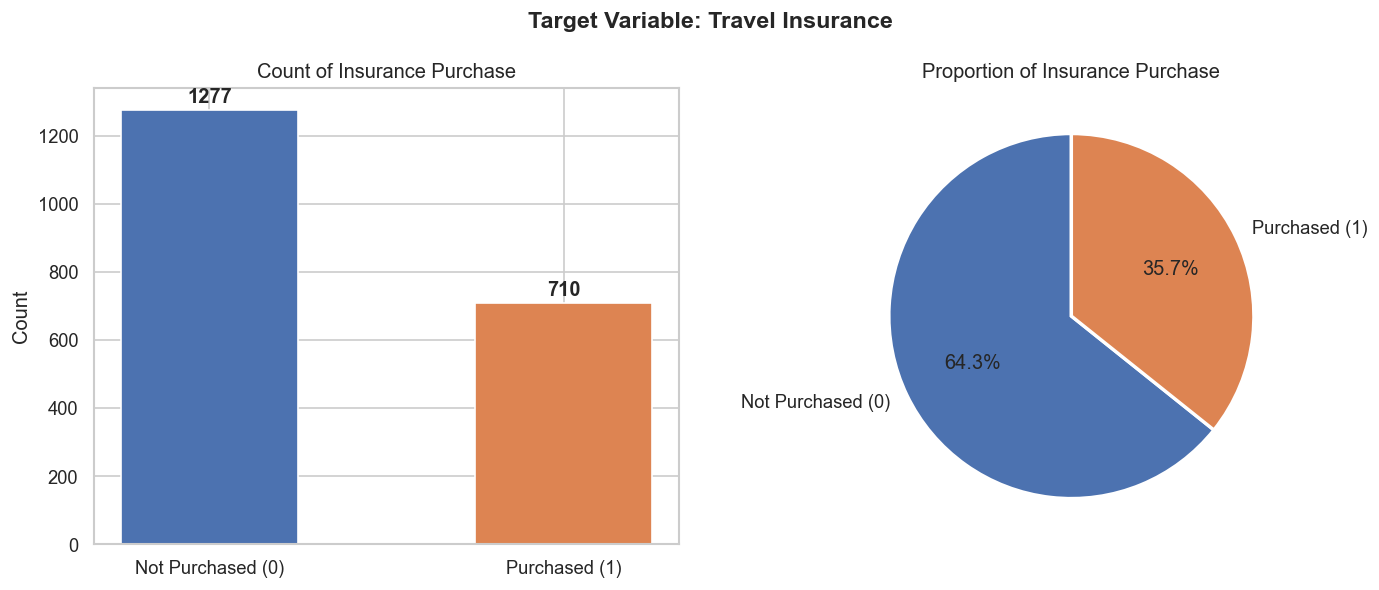

Saved: viz1_target_distribution.png


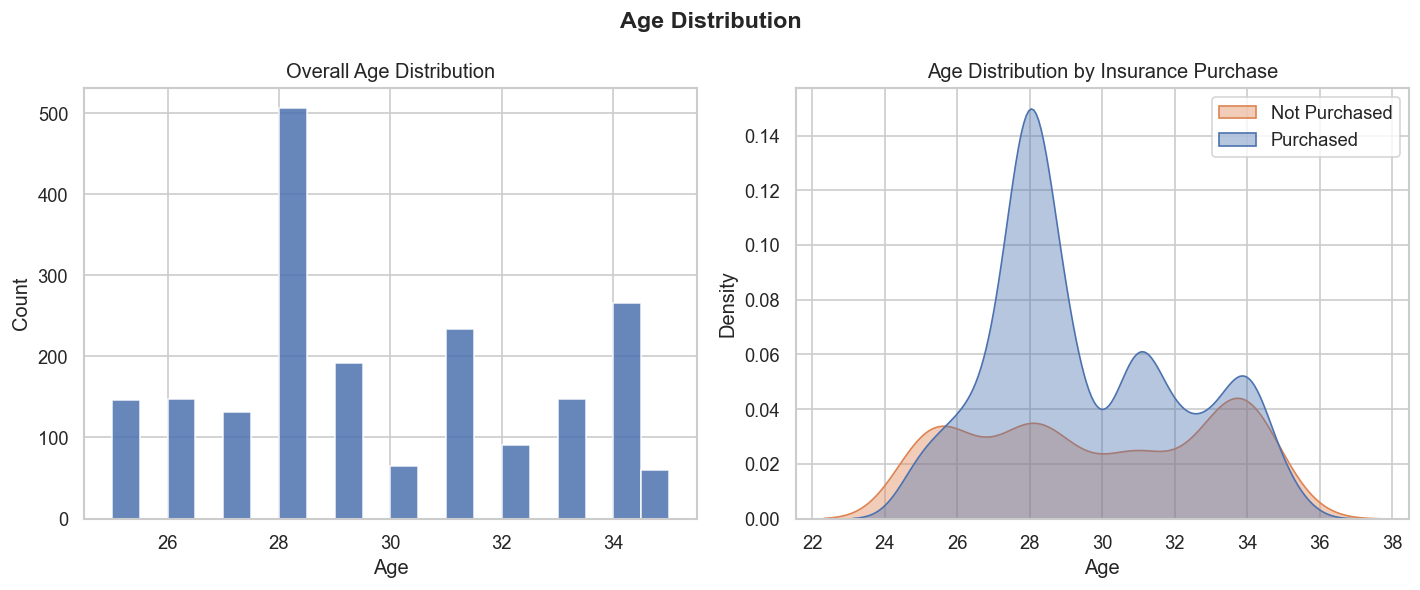

Saved: viz1_age_distribution.png


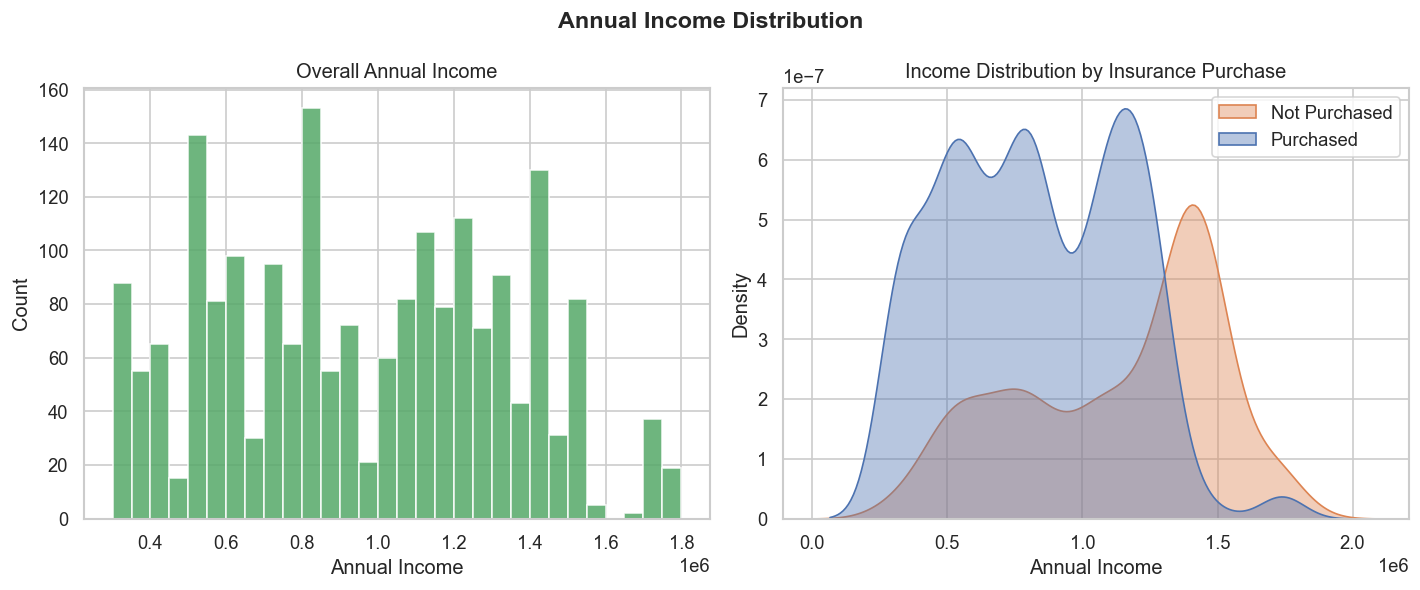

Saved: viz1_income_distribution.png


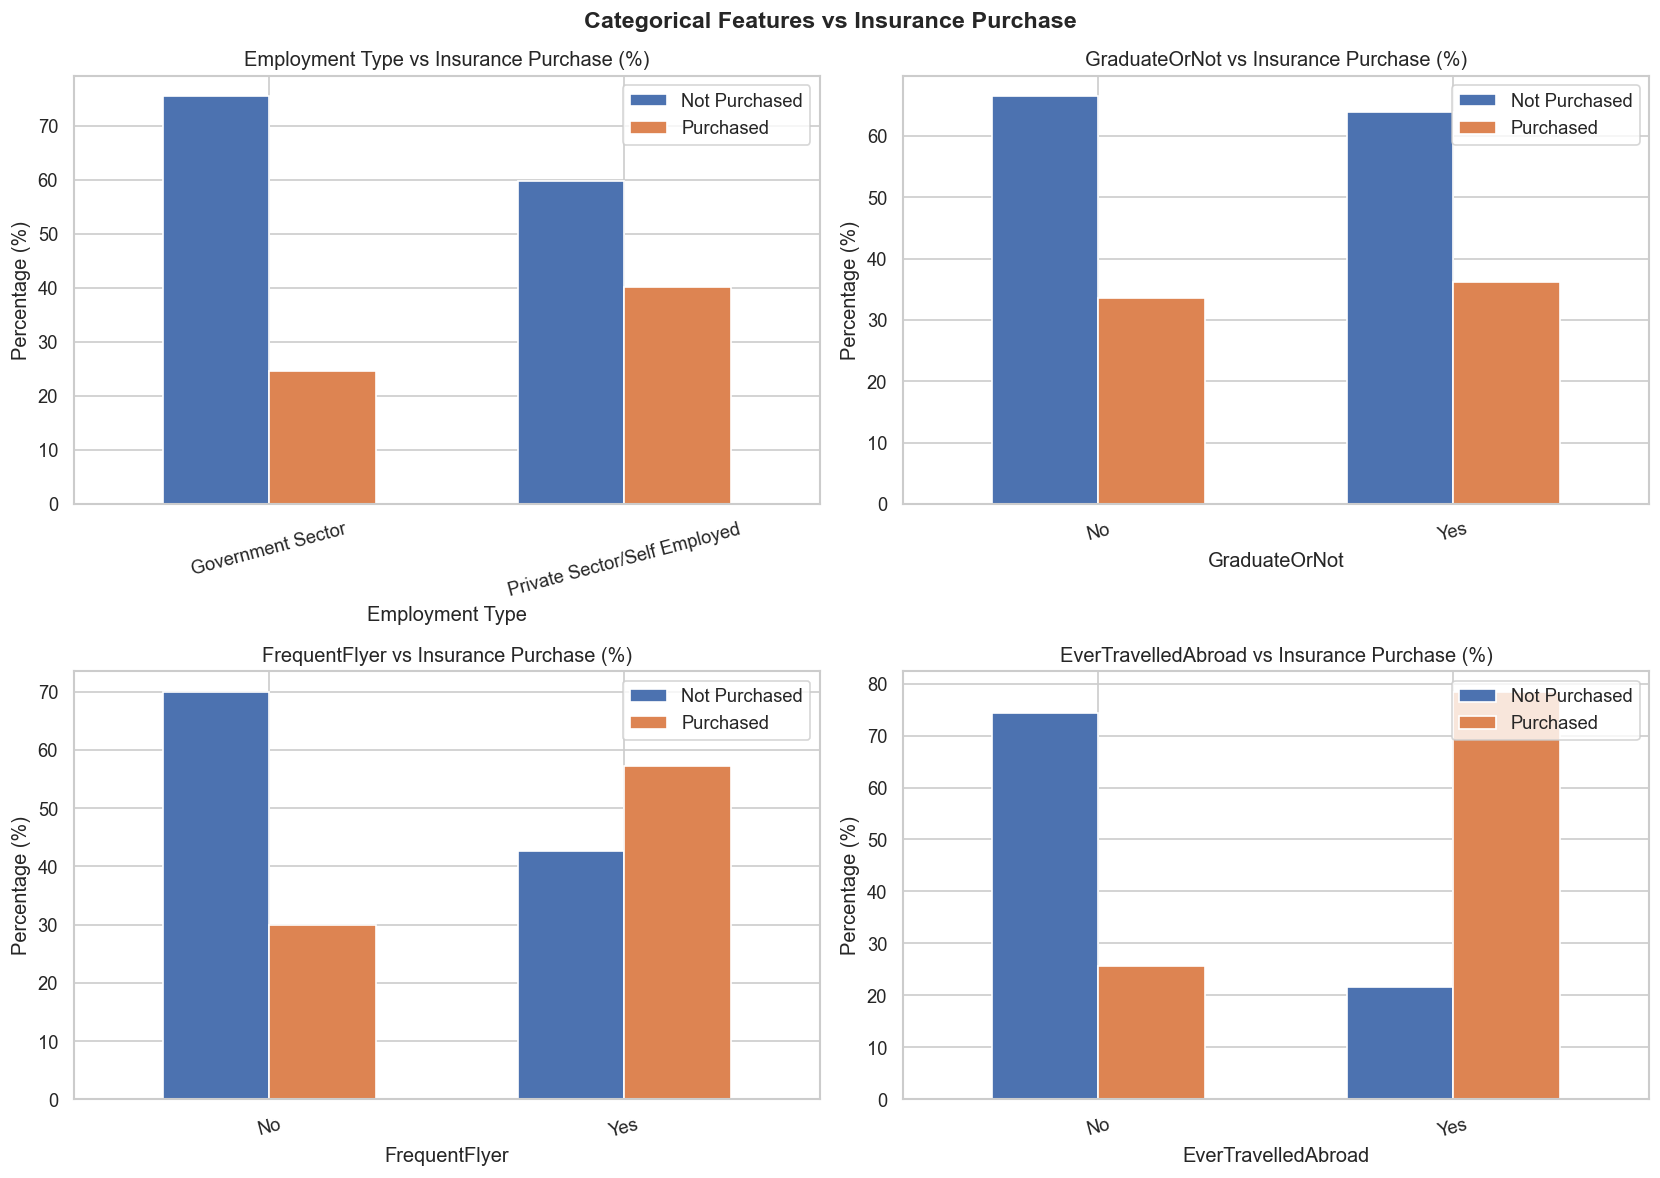

Saved: viz1_categorical_vs_target.png


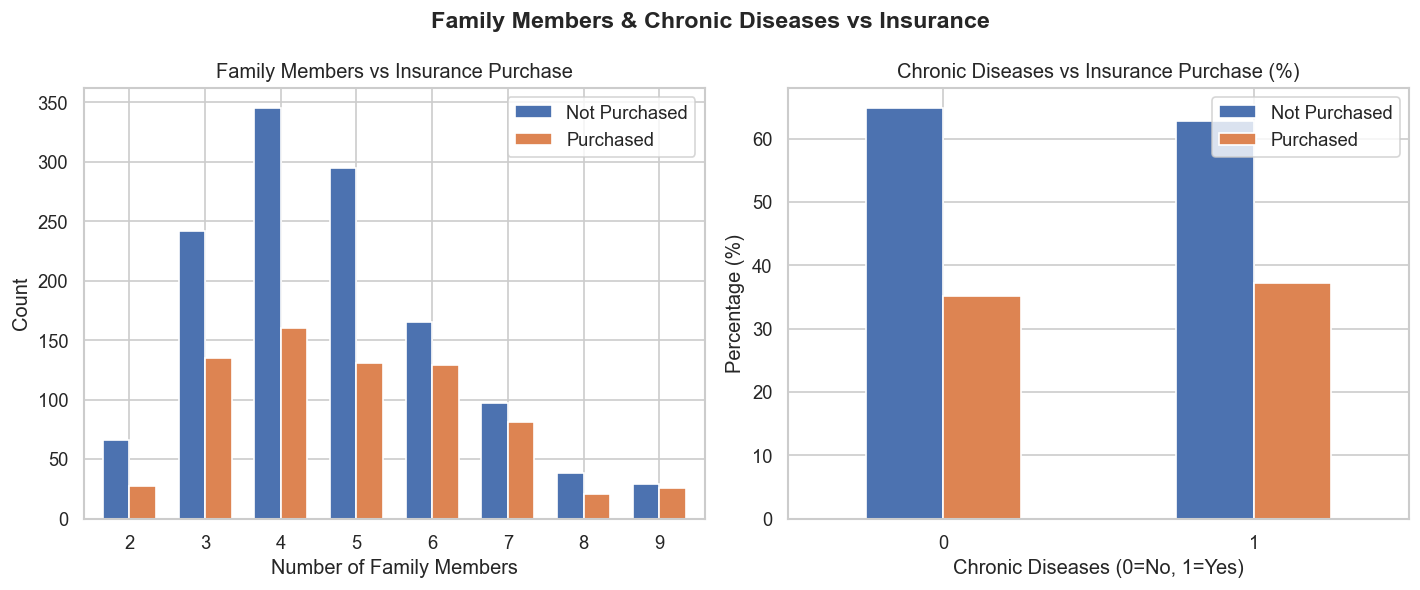

Saved: viz1_family_chronic.png

✅ Data Visualization Part 1 Complete!


In [11]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

# ------------------------------------------------------------
# 2. Basic Statistics
# ------------------------------------------------------------
print("\nDescriptive Statistics:\n", df.describe(include="all"))
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df["TravelInsurance"].value_counts())

# ------------------------------------------------------------
# 3. Target Variable Distribution
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Target Variable: Travel Insurance", fontsize=14, fontweight="bold")

counts = df["TravelInsurance"].value_counts()
labels = ["Not Purchased (0)", "Purchased (1)"]

axes[0].bar(labels, counts.values, color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.5)
axes[0].set_title("Count of Insurance Purchase")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=labels, autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proportion of Insurance Purchase")

plt.tight_layout()
plt.savefig("viz1_target_distribution.png", bbox_inches="tight")
plt.show()
print("Saved: viz1_target_distribution.png")

# ------------------------------------------------------------
# 4. Age Distribution
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Age Distribution", fontsize=14, fontweight="bold")

axes[0].hist(df["Age"], bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].set_title("Overall Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

sns.kdeplot(data=df, x="Age", hue="TravelInsurance", ax=axes[1],
            fill=True, alpha=0.4, palette=["#4C72B0", "#DD8452"])
axes[1].set_title("Age Distribution by Insurance Purchase")
axes[1].set_xlabel("Age")
axes[1].legend(["Not Purchased", "Purchased"])

plt.tight_layout()
plt.savefig("viz1_age_distribution.png", bbox_inches="tight")
plt.show()
print("Saved: viz1_age_distribution.png")

# ------------------------------------------------------------
# 5. Annual Income Distribution
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Annual Income Distribution", fontsize=14, fontweight="bold")

axes[0].hist(df["AnnualIncome"], bins=30, color="#55A868", edgecolor="white", alpha=0.85)
axes[0].set_title("Overall Annual Income")
axes[0].set_xlabel("Annual Income")
axes[0].set_ylabel("Count")

sns.kdeplot(data=df, x="AnnualIncome", hue="TravelInsurance", ax=axes[1],
            fill=True, alpha=0.4, palette=["#4C72B0", "#DD8452"])
axes[1].set_title("Income Distribution by Insurance Purchase")
axes[1].set_xlabel("Annual Income")
axes[1].legend(["Not Purchased", "Purchased"])

plt.tight_layout()
plt.savefig("viz1_income_distribution.png", bbox_inches="tight")
plt.show()
print("Saved: viz1_income_distribution.png")

# ------------------------------------------------------------
# 6. Categorical Features vs Target
# ------------------------------------------------------------
cat_cols = ["Employment Type", "GraduateOrNot", "FrequentFlyer", "EverTravelledAbroad"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Categorical Features vs Insurance Purchase", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["TravelInsurance"], normalize="index") * 100
    ct.columns = ["Not Purchased", "Purchased"]
    ct.plot(kind="bar", ax=axes[i], color=["#4C72B0", "#DD8452"],
            edgecolor="white", rot=15, width=0.6)
    axes[i].set_title(f"{col} vs Insurance Purchase (%)")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].set_xlabel(col)
    axes[i].legend(loc="upper right")

plt.tight_layout()
plt.savefig("viz1_categorical_vs_target.png", bbox_inches="tight")
plt.show()
print("Saved: viz1_categorical_vs_target.png")

# ------------------------------------------------------------
# 7. Family Members & Chronic Diseases
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Family Members & Chronic Diseases vs Insurance", fontsize=14, fontweight="bold")

# Family members
fm_ct = pd.crosstab(df["FamilyMembers"], df["TravelInsurance"])
fm_ct.columns = ["Not Purchased", "Purchased"]
fm_ct.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"],
           edgecolor="white", rot=0, width=0.7)
axes[0].set_title("Family Members vs Insurance Purchase")
axes[0].set_xlabel("Number of Family Members")
axes[0].set_ylabel("Count")

# Chronic diseases
cd_ct = pd.crosstab(df["ChronicDiseases"], df["TravelInsurance"], normalize="index") * 100
cd_ct.columns = ["Not Purchased", "Purchased"]
cd_ct.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"],
           edgecolor="white", rot=0, width=0.5)
axes[1].set_title("Chronic Diseases vs Insurance Purchase (%)")
axes[1].set_xlabel("Chronic Diseases (0=No, 1=Yes)")
axes[1].set_ylabel("Percentage (%)")

plt.tight_layout()
plt.savefig("viz1_family_chronic.png", bbox_inches="tight")
plt.show()
print("Saved: viz1_family_chronic.png")

print("\n✅ Data Visualization Part 1 Complete!")